# Zomato Restaurant Success Factors Analysis  
### Exploratory Data Analysis (EDA)

<img src="https://upload.wikimedia.org/wikipedia/commons/7/75/Zomato_logo.png" width="300"/>

*Image source: Zomato (used for educational purposes only)*


### Assignment Objective

The objective of this assignment is to perform Exploratory Data Analysis (EDA) on the Indian Restaurants dataset to identify factors that influence restaurant success on Zomato. Restaurant success is measured using customer ratings, along with features such as location, cuisine, pricing, and online services.

#### Import Required Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


#### Load the Dataset

In [31]:
df = pd.read_csv("Indian-Resturants.csv")
df.head()


,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


#### Dataset Overview

In [32]:
df.shape


(211944, 26)

### This shows the number of rows and columns in the dataset

In [33]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211944 entries, 0 to 211943
Data columns (total 26 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   res_id                211944 non-null  int64  
 1   name                  211944 non-null  object 
 2   establishment         211944 non-null  object 
 3   url                   211944 non-null  object 
 4   address               211810 non-null  object 
 5   city                  211944 non-null  object 
 6   city_id               211944 non-null  int64  
 7   locality              211944 non-null  object 
 8   latitude              211944 non-null  float64
 9   longitude             211944 non-null  float64
 10  zipcode               48757 non-null   object 
 11  country_id            211944 non-null  int64  
 12  locality_verbose      211944 non-null  object 
 13  cuisines              210553 non-null  object 
 14  timings               208070 non-null  object 
 15  

### This helps understand column names, data types, and missing values.

## Check Missing Values

In [34]:
df.isnull().sum()


res_id                       0
name                         0
establishment                0
url                          0
address                    134
city                         0
city_id                      0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
country_id                   0
locality_verbose             0
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
opentable_support           48
delivery                     0
takeaway                     0
dtype: int64

### This identifies columns containing missing data.

## Check Duplicate Records

In [35]:
df.duplicated().sum()


np.int64(151527)

### This checks whether duplicate rows exist in the dataset.

## Data Cleaning

In [36]:
df.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [37]:
df = df.drop_duplicates()
df = df.dropna(subset=["aggregate_rating"])

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])


### This safely removes duplicates and handles missing values using the correct rating column.

## Average Rating

In [38]:
df["aggregate_rating"].mean()


np.float64(3.032868232451132)

### This calculates the overall average restaurant rating.

## Distribution of Restaurant Ratings

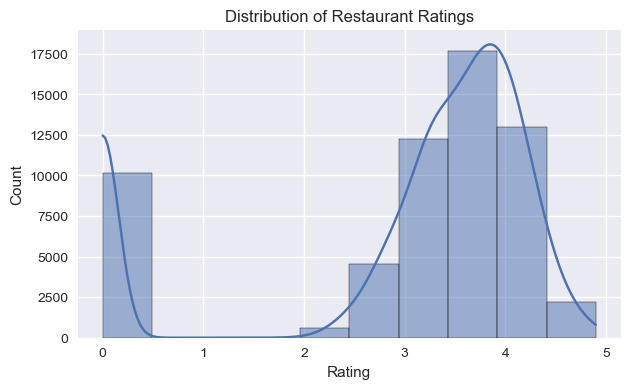

In [39]:
plt.figure(figsize=(7,4))
sns.histplot(df["aggregate_rating"], bins=10, kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


### This shows how ratings are spread across restaurants.

## Ratings Across Cities

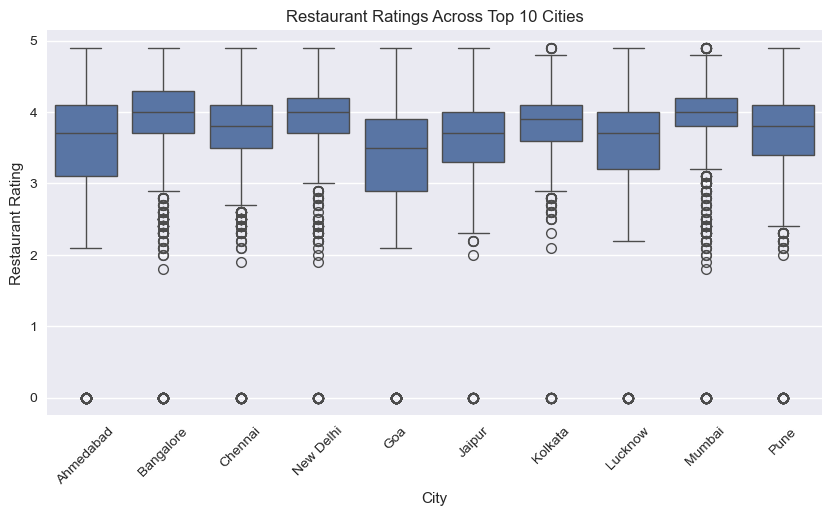

In [40]:
top_cities = df["city"].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.boxplot(
    x="city",
    y="aggregate_rating",
    data=df[df["city"].isin(top_cities)]
)
plt.title("Restaurant Ratings Across Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Restaurant Rating")
plt.xticks(rotation=45)
plt.show()


### This compares rating distribution across different cities.

## Cuisine Variety vs Rating

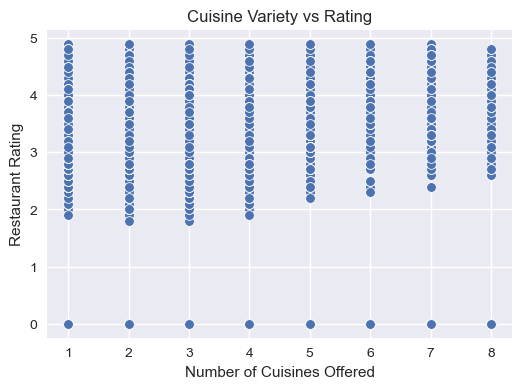

In [41]:
df["cuisines_count"] = df["cuisines"].apply(lambda x: len(str(x).split(",")))

plt.figure(figsize=(6,4))
sns.scatterplot(
    x="cuisines_count",
    y="aggregate_rating",
    data=df
)
plt.title("Cuisine Variety vs Rating")
plt.xlabel("Number of Cuisines Offered")
plt.ylabel("Restaurant Rating")
plt.show()


### This checks whether offering more cuisines affects ratings.

## Price Range vs Rating

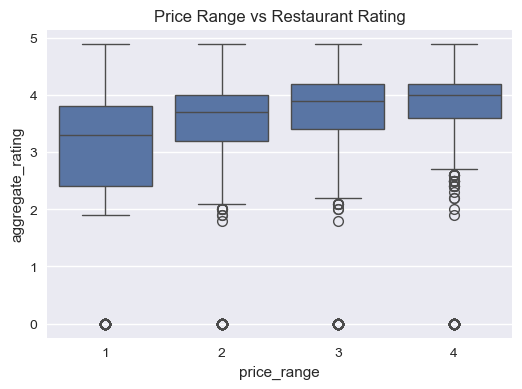

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x="price_range", y="aggregate_rating", data=df)
plt.title("Price Range vs Restaurant Rating")
plt.show()


### This analyzes the relationship between pricing and ratings.

## Online Order vs Rating

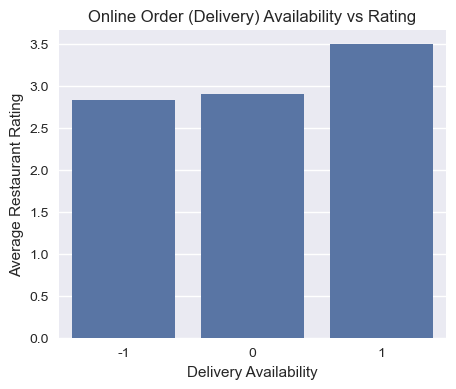

In [43]:
plt.figure(figsize=(5,4))
sns.barplot(
    x="delivery",
    y="aggregate_rating",
    data=df,
    errorbar=None
)
plt.title("Online Order (Delivery) Availability vs Rating")
plt.xlabel("Delivery Availability")
plt.ylabel("Average Restaurant Rating")
plt.show()


### This compares ratings for restaurants with and without online ordering.

## Takeaway Availability vs Rating

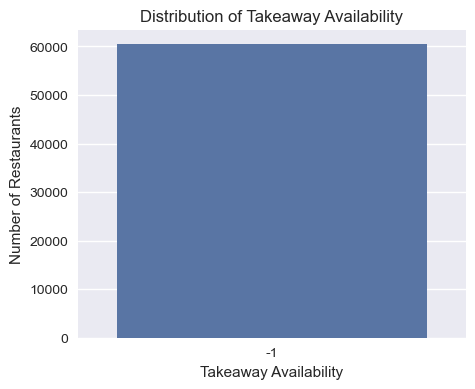

In [44]:
plt.figure(figsize=(5,4))
sns.countplot(
    x="takeaway",
    data=df
)
plt.title("Distribution of Takeaway Availability")
plt.xlabel("Takeaway Availability")
plt.ylabel("Number of Restaurants")
plt.show()


### A bar plot is used to compare the average restaurant ratings based on takeaway availability

## Horizontal Bar Chart (Multicolor)

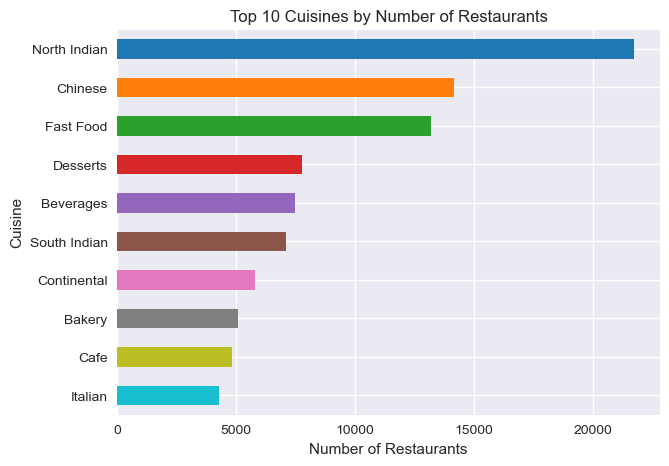

In [45]:
top_cuisines = (
    df["cuisines"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(7,5))
top_cuisines.plot(
    kind="barh",
    color=plt.cm.tab10.colors
)
plt.title("Top 10 Cuisines by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")
plt.gca().invert_yaxis()
plt.show()


### A horizontal multicolor bar chart is used to show the most popular cuisines based on restaurant count.

In [46]:
df["city"].unique()


array(['Agra', 'Ahmedabad', 'Gandhinagar', 'Ajmer', 'Alappuzha',
       'Allahabad', 'Amravati', 'Amritsar', 'Aurangabad', 'Bangalore',
       'Bhopal', 'Bhubaneshwar', 'Chandigarh', 'Mohali', 'Panchkula',
       'Zirakpur', 'Nayagaon', 'Chennai', 'Coimbatore', 'Cuttack',
       'Darjeeling', 'Dehradun', 'New Delhi', 'Gurgaon', 'Noida',
       'Faridabad', 'Ghaziabad', 'Greater Noida', 'Dharamshala',
       'Gangtok', 'Goa', 'Gorakhpur', 'Guntur', 'Guwahati', 'Gwalior',
       'Haridwar', 'Hyderabad', 'Secunderabad', 'Indore', 'Jabalpur',
       'Jaipur', 'Jalandhar', 'Jammu', 'Jamnagar', 'Jamshedpur', 'Jhansi',
       'Jodhpur', 'Junagadh', 'Kanpur', 'Kharagpur', 'Kochi', 'Kolhapur',
       'Kolkata', 'Howrah', 'Kota', 'Lucknow', 'Ludhiana', 'Madurai',
       'Manali', 'Mangalore', 'Manipal', 'Udupi', 'Meerut', 'Mumbai',
       'Thane', 'Navi Mumbai', 'Mussoorie', 'Mysore', 'Nagpur',
       'Nainital', 'Nasik', 'Nashik', 'Neemrana', 'Ooty', 'Palakkad',
       'Patiala', 'Patna', 'Pudu

In [47]:
city_rating = df.groupby("city")["aggregate_rating"].mean().sort_values(ascending=False).head(10)
city_rating


city
Gurgaon         3.872549
Secunderabad    3.848454
Mumbai          3.795863
Hyderabad       3.775751
New Delhi       3.770005
Kolkata         3.767233
Bangalore       3.729641
Chennai         3.667764
Noida           3.651648
Navi Mumbai     3.546094
Name: aggregate_rating, dtype: float64

### The unique and groupby functions are used to identify cities and calculate their average restaurant ratings.

## Density Plot (KDE)

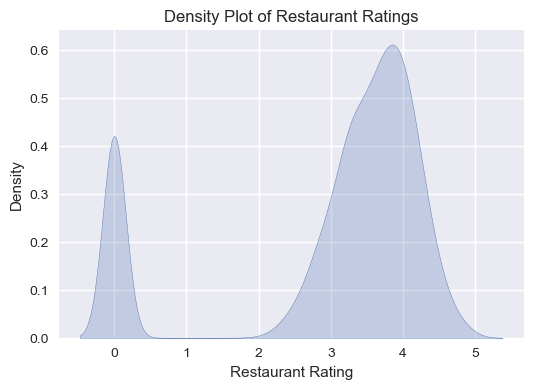

In [48]:
plt.figure(figsize=(6,4))
sns.kdeplot(
    df["aggregate_rating"],
    fill=True
)
plt.title("Density Plot of Restaurant Ratings")
plt.xlabel("Restaurant Rating")
plt.ylabel("Density")
plt.show()


### A density plot is used to understand the concentration and distribution of restaurant ratings

# conclusion

#### This exploratory data analysis highlights that restaurant success on Zomato is influenced by factors such as delivery availability, pricing, cuisine variety, and customer convenience. Restaurants with moderate pricing and online delivery options tend to receive better ratings. Overall, focusing on service quality and customer accessibility can significantly improve restaurant performance.